<a href="https://colab.research.google.com/github/agief-G1A024037/TugasAIKetiga/blob/main/Tugas2Module2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas 3 - Artificial Intelligence: Linear Regression & Classification
**Dosen Pengampu:** [Nama Dosen]

---

### Informasi Kelompok
* **Anggota :** Muhammad Iqbal Zafarullah (G1A024007) & Agief Vemas (G1A024037)
* **Repository GitHub:** [Tempel Link GitHub Kamu di Sini]


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
import os
print(os.listdir())

['.config', 'sample_data']


In [10]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [11]:
train = pd.read_csv('/content/train.csv')

X = train[['ram', 'battery_power']].values
y = train['price_range'].values

print(X.shape, y.shape)

(2000, 2) (2000,)


In [12]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

print(f"Data dimuat: {X.shape[0]} baris, {X.shape[1]} fitur.")

Data dimuat: 2000 baris, 2 fitur.


In [13]:
def softmax(z):
    # Stabilisasi numerik dengan mengurangi nilai maksimum
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(y_true, y_pred):
    # Implementasi Cross-Entropy Loss [cite: 47]
    n_samples = y_true.shape[0]
    # Mengambil probabilitas pada index kelas yang benar
    corect_logprobs = -np.log(y_pred[range(n_samples), y_true] + 1e-15)
    return np.sum(corect_logprobs) / n_samples

In [ ]:
def train_model(X, y, lr=0.01, epochs=50):
    n_samples, n_features = X.shape
    n_classes = len(np.unique(y))

    # Inisialisasi Parameter (Weight dan Bias)
    # Jumlah parameter: (2 fitur * 4 kelas) + 4 bias = 12 [cite: 42]
    W = np.random.randn(n_features, n_classes) * 0.01
    b = np.zeros(n_classes)

    losses = []

    for epoch in range(epochs):
        # Shuffle data untuk karakteristik "Stochastic"
        indices = np.random.permutation(n_samples)
        X_sh = X[indices]
        y_sh = y[indices]

        for i in range(n_samples):
            xi = X_sh[i:i+1]
            yi = y_sh[i]

            # Forward Pass
            z = np.dot(xi, W) + b
            probs = softmax(z)

            # Hitung Gradient (Error)
            dz = probs.copy()
            dz[0, yi] -= 1

            # Update Weight dan Bias
            dW = np.dot(xi.T, dz)
            db = np.sum(dz, axis=0)

            W -= lr * dW
            b -= lr * db

        # Simpan loss untuk monitoring
        full_pred = softmax(np.dot(X, W) + b)
        loss = compute_loss(y, full_pred)
        losses.append(loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

    return W, b, losses

# Jalankan pelatihan
W, b, history = train_model(X, y)

Epoch 10/50, Loss: 0.4502
Epoch 20/50, Loss: 0.4150
Epoch 30/50, Loss: 0.4038
Epoch 40/50, Loss: 0.4004
Epoch 50/50, Loss: 0.3984


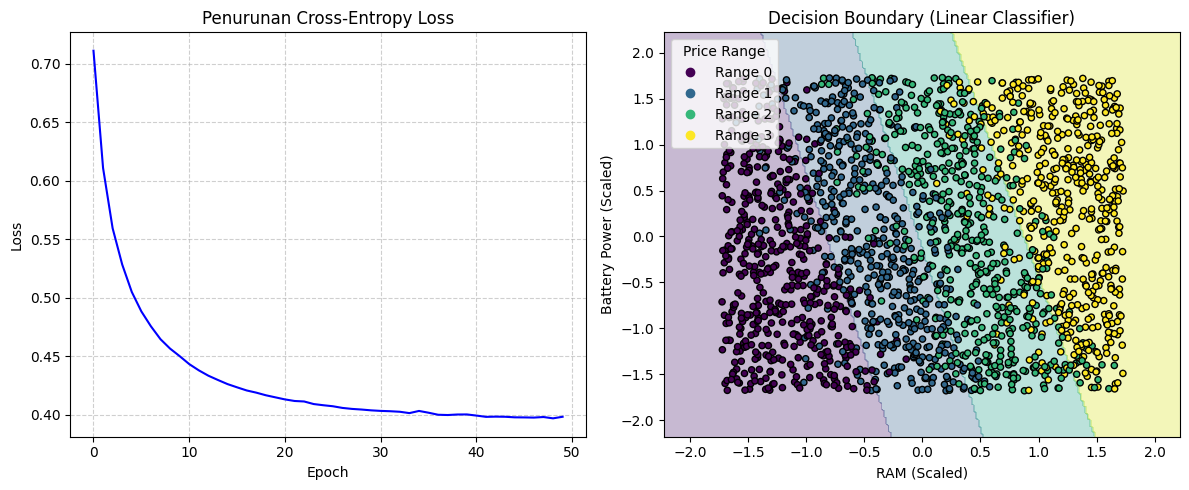

In [ ]:
def plot_results(X, y, W, b, history):
    plt.figure(figsize=(12, 5))

    # 1. Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history, color='blue')
    plt.title("Penurunan Cross-Entropy Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. Plot Decision Boundary [cite: 49]
    plt.subplot(1, 2, 2)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Hitung skor prediksi untuk seluruh area grid
    Z = np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b
    Z = np.argmax(Z, axis=1)
    Z = Z.reshape(xx.shape)

    # Gambar area klasifikasi (Voronoi Regions)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

    # Gambar titik data asli
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20, cmap='viridis')

    # --- TAMBAHKAN LEGENDA DI SINI ---
    classes = ['Range 0', 'Range 1', 'Range 2', 'Range 3'] # [cite: 40]
    plt.legend(handles=scatter.legend_elements()[0], labels=classes, title="Price Range")
    # ---------------------------------

    plt.title("Decision Boundary (Linear Classifier)")
    plt.xlabel("RAM (Scaled)")
    plt.ylabel("Battery Power (Scaled)")
    plt.tight_layout()
    plt.show()

# Jalankan fungsi
plot_results(X, y, W, b, history)